In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/refs/heads/master/data/air-passengers.csv')
df.head(3)

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132


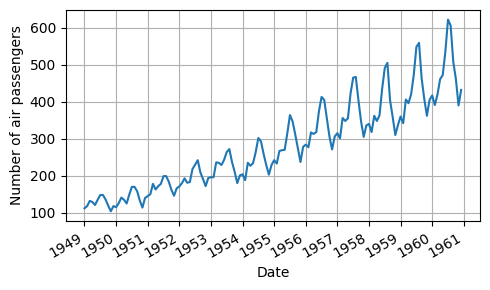

In [7]:
fig, ax = plt.subplots(figsize = (5, 3))

ax.plot(df['Month'], df['Passengers'])
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')
plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

plt.grid(True)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Time Series Decomposition

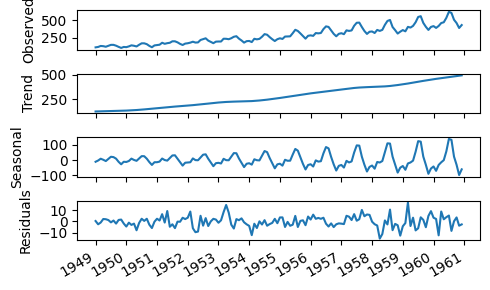

In [11]:
decomposition = STL(df['Passengers'], period=12).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(5, 3))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### **Forecasting using ARIMA**

In [16]:
ad_fuller_result = adfuller(df['Passengers'])
print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641


#### **First Order Linear Differencing**

In [17]:
df_diff = np.diff(df['Passengers'], n=1)
ad_fuller_result = adfuller(df_diff)
print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -2.8292668241700047
p-value: 0.05421329028382478


#### **Second Order Linear Differencing**

In [18]:
df_diff2 = np.diff(df_diff, n=1)
ad_fuller_result = adfuller(df_diff2)
print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -16.384231542468513
p-value: 2.7328918500142026e-29


In [19]:
ps = range(0, 13, 1)
qs = range(0, 13, 1)
Ps = [0]
Qs = [0]
d = 2
D = 0
s = 12
ARIMA_order_list = list(product(ps, qs, Ps, Qs))
print(ARIMA_order_list)

[(0, 0, 0, 0), (0, 1, 0, 0), (0, 2, 0, 0), (0, 3, 0, 0), (0, 4, 0, 0), (0, 5, 0, 0), (0, 6, 0, 0), (0, 7, 0, 0), (0, 8, 0, 0), (0, 9, 0, 0), (0, 10, 0, 0), (0, 11, 0, 0), (0, 12, 0, 0), (1, 0, 0, 0), (1, 1, 0, 0), (1, 2, 0, 0), (1, 3, 0, 0), (1, 4, 0, 0), (1, 5, 0, 0), (1, 6, 0, 0), (1, 7, 0, 0), (1, 8, 0, 0), (1, 9, 0, 0), (1, 10, 0, 0), (1, 11, 0, 0), (1, 12, 0, 0), (2, 0, 0, 0), (2, 1, 0, 0), (2, 2, 0, 0), (2, 3, 0, 0), (2, 4, 0, 0), (2, 5, 0, 0), (2, 6, 0, 0), (2, 7, 0, 0), (2, 8, 0, 0), (2, 9, 0, 0), (2, 10, 0, 0), (2, 11, 0, 0), (2, 12, 0, 0), (3, 0, 0, 0), (3, 1, 0, 0), (3, 2, 0, 0), (3, 3, 0, 0), (3, 4, 0, 0), (3, 5, 0, 0), (3, 6, 0, 0), (3, 7, 0, 0), (3, 8, 0, 0), (3, 9, 0, 0), (3, 10, 0, 0), (3, 11, 0, 0), (3, 12, 0, 0), (4, 0, 0, 0), (4, 1, 0, 0), (4, 2, 0, 0), (4, 3, 0, 0), (4, 4, 0, 0), (4, 5, 0, 0), (4, 6, 0, 0), (4, 7, 0, 0), (4, 8, 0, 0), (4, 9, 0, 0), (4, 10, 0, 0), (4, 11, 0, 0), (4, 12, 0, 0), (5, 0, 0, 0), (5, 1, 0, 0), (5, 2, 0, 0), (5, 3, 0, 0), (5, 4, 0, 0), (5, 

In [20]:
def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
  results = []
  for order in tqdm_notebook(order_list):
    try:
      model = SARIMAX(endog, order=(order[0], d, order[1]), seasonal_order=(order[2], D, order[3], s), simple_differencing=False).fit(disp=False)
    except:
      continue

    aic = model.aic
    results.append([order, aic])
  result_df = pd.DataFrame(results)
  result_df.columns = ['(p,q,P,Q)', 'AIC']

  #Sort in ascending order, lower AIC is better
  result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
  return result_df

In [21]:
ARIMA_order_list = list(product(ps, qs, Ps, Qs))

train = df['Passengers'][:-12]

ARIMA_result_df = optimize_SARIMA(train, ARIMA_order_list, d, D, s)
ARIMA_result_df

  0%|          | 0/169 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(11, 3, 0, 0)",1016.841988
1,"(11, 4, 0, 0)",1019.034841
2,"(11, 5, 0, 0)",1020.377910
3,"(12, 0, 0, 0)",1020.942325
4,"(11, 1, 0, 0)",1021.025580
...,...,...
164,"(5, 0, 0, 0)",1281.732157
165,"(3, 0, 0, 0)",1300.282335
166,"(2, 0, 0, 0)",1302.913196
167,"(1, 0, 0, 0)",1308.152194


This returns a DataFrame where the model with the lowest AIC is a
SARIMA(11,2,3)(0,0,0)12 model, which is equivalent to an ARIMA(11,2,3) model.

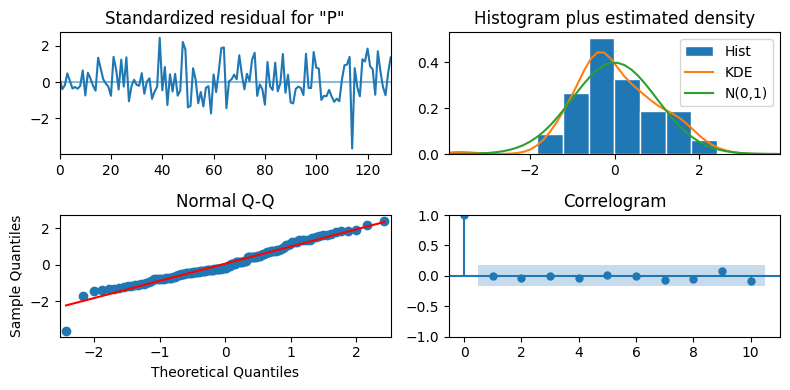

In [25]:
ARIMA_model = SARIMAX(train, order=(11,2,3), simple_differencing=False)
ARIMA_model_fit = ARIMA_model.fit(disp=False)
ARIMA_model_fit.plot_diagnostics(figsize=(8,4));
plt.tight_layout()
plt.show()

From the diagnostics:
* Top-left plot (residuals over time) → No trend, constant spread → looks random.
* Top-right plot (distribution) → Close to normal bell curve, though with a small peak.
* Q-Q plot (bottom-left) → Points lie almost on the straight line → confirms near-normal distribution.
* Correlogram (bottom-right) → No significant correlations after lag 0 → means no leftover patterns.

**In short**: The residuals behave like white noise, which is good. It means the ARIMA(11,2,3) model has captured most of the structure in the data, leaving only random noise behind.

In [24]:
from statsmodels.stats.diagnostic import acorr_ljungbox
residuals = ARIMA_model_fit.resid
lj_df = acorr_ljungbox(residuals, np.arange(1, 11, 1))
lj_df

,lb_stat,lb_pvalue
1,6.551733,0.010478
2,6.678223,0.035468
3,6.955162,0.073341
4,7.748964,0.101219
5,8.392800,0.135875
6,8.678755,0.192467
7,9.493079,0.219165
8,9.731334,0.284391
9,9.741643,0.371803
10,11.533096,0.317519


* The Ljung-Box test checks if the residuals (errors left after fitting the model) are random or if they still have patterns.
* If p-values are less than 0.05, it means there’s still correlation (not fully random).
* In this case, the first two lags show correlation, but from lag 3 onward, the residuals look random.
* Graphs of the residuals suggest they behave like white noise (random), but the test says the ARIMA model missed some information at the first two lags.
* That’s expected because we used a non-seasonal ARIMA on seasonal data.

In short: The ARIMA model isn’t perfect here — it misses some seasonal structure. That’s why SARIMA, which handles seasonality, is the better choice for forecasting airline passengers.

In [27]:
test = df.iloc[-12:]
test['naive_seasonal'] = df['Passengers'].iloc[120:132].values

ARIMA_pred = ARIMA_model_fit.get_prediction(132, 143).predicted_mean
test['ARIMA_pred'] = ARIMA_pred

# **Forecasting with a SARIMA(p,d,q)($P,D,Q$)$_m$ model**

#### **Seasonal Differencing**

In [28]:
df_diff_seasonal_diff = np.diff(df_diff, n=12)
ad_fuller_result = adfuller(df_diff_seasonal_diff)
print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -17.62486236026156
p-value: 3.823046855601547e-30


In [29]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)
Ps = range(0, 4, 1)
Qs = range(0, 4, 1)
SARIMA_order_list = list(product(ps, qs, Ps, Qs))
train = df['Passengers'][:-12]
d = 1
D = 1
s = 12

In [30]:
SARIMA_result_df = optimize_SARIMA(train, SARIMA_order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/256 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(2, 1, 1, 2)",892.251468
1,"(2, 1, 1, 3)",894.094295
2,"(2, 1, 2, 1)",894.147180
3,"(1, 0, 1, 2)",894.287629
4,"(0, 1, 1, 2)",894.990210
...,...,...
250,"(0, 0, 2, 0)",906.940147
251,"(3, 2, 0, 3)",907.181875
252,"(0, 0, 3, 2)",907.451095
253,"(0, 0, 3, 0)",908.742583


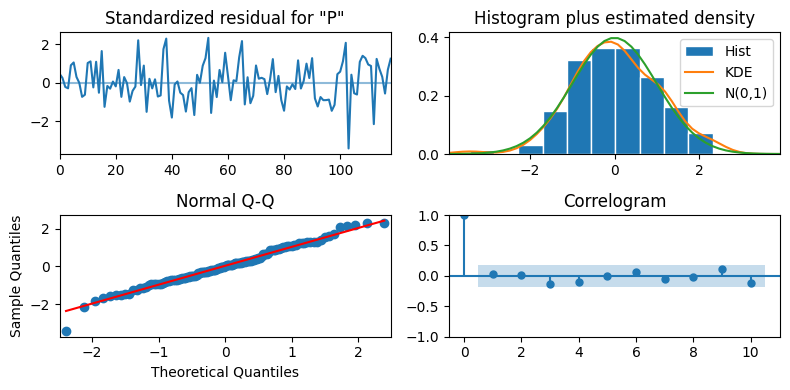

In [38]:
SARIMA_model = SARIMAX(train, order=(2,1,1), seasonal_order=(1,1,2,12), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)
SARIMA_model_fit.plot_diagnostics(figsize=(8, 4))
plt.tight_layout()
plt.show()

In [32]:
residuals = SARIMA_model_fit.resid
ljung_sarima_res = acorr_ljungbox(residuals, np.arange(1, 11, 1))
ljung_sarima_res

,lb_stat,lb_pvalue
1,0.004900,0.944192
2,0.742117,0.690004
3,1.017222,0.797085
4,1.221722,0.874509
5,1.431753,0.920809
6,1.710553,0.944304
7,2.306753,0.940933
8,2.715821,0.950907
9,2.732092,0.973977
10,4.968883,0.893247


The returned p-values are all greater than 0.05. Therefore, we do not reject the null hypothesis, and we conclude that the residuals are independent and uncorrelated, just like white noise

In [33]:
SARIMA_pred = SARIMA_model_fit.get_prediction(132, 143).predicted_mean
test['SARIMA_pred'] = SARIMA_pred

#### **Comparing the performance of each forecasting method**

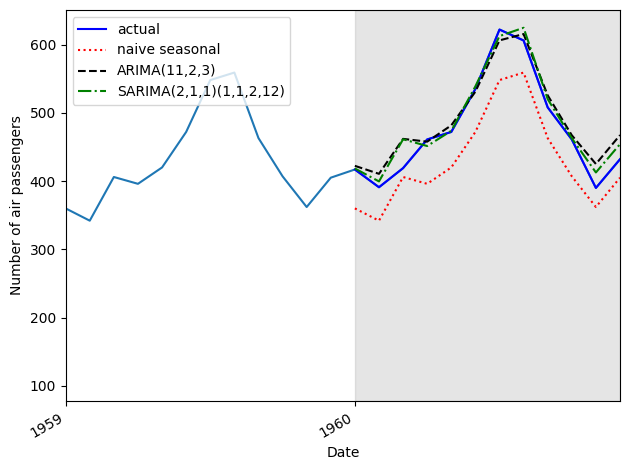

In [34]:
fig, ax = plt.subplots()
ax.plot(df['Month'], df['Passengers'])
ax.plot(test['Passengers'], 'b-', label='actual')
ax.plot(test['naive_seasonal'], 'r:', label='naive seasonal')
ax.plot(test['ARIMA_pred'], 'k--', label='ARIMA(11,2,3)')
ax.plot(test['SARIMA_pred'], 'g-.', label='SARIMA(2,1,1)(1,1,2,12)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')
ax.axvspan(132, 143, color='#808080', alpha=0.2)
ax.legend(loc=2)
plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))
ax.set_xlim(120, 143)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

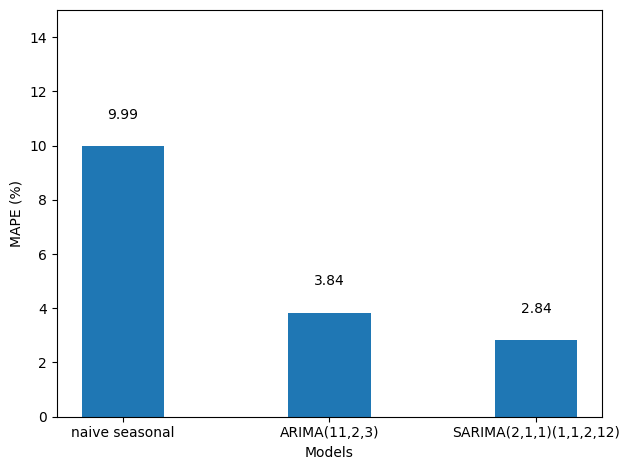

In [37]:
def mape(y_true, y_pred):
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_naive_seasonal = mape(test['Passengers'], test['naive_seasonal'])
mape_ARIMA = mape(test['Passengers'], test['ARIMA_pred'])
mape_SARIMA = mape(test['Passengers'], test['SARIMA_pred'])
fig, ax = plt.subplots()
x = ['naive seasonal', 'ARIMA(11,2,3)', 'SARIMA(2,1,1)(1,1,2,12)']
y = [mape_naive_seasonal, mape_ARIMA, mape_SARIMA]
ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)
for index, value in enumerate(y):
  plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center')
  plt.tight_layout()